# Multiple Linear Regression from Scratch — Citibike Demand Prediction

The goal of this notebook is to implement **Multiple Linear Regression from scratch** to predict hourly Citibike demand `ride_counts` across Manhattan and Brooklyn neighborhoods.

We will:
* Load and explore the aggregated hourly neighborhood dataset
* Preprocess features (one-hot encoding, standardization)
* **Log-transform** the target variable to handle right-skewed demand distribution
* Split data chronologically into train / validation / test sets (70/15/15)
* Implement Multiple Linear Regression using:
  * **Normal Equation** (closed-form solution)
  * **Gradient Descent** (iterative optimization)
* Evaluate models using RMSE, MAE, and R² (in both log-space and original scale)
* Inspect and interpret model coefficients
* Visualize predictions and learning curves

---
# 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the aggregated hourly neighborhood dataset
df = pd.read_csv('datasets/hourly_neighborhood_2025.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (569399, 15)


,hour_slot,NTA2020,NTAName,BoroName,ride_count,mean_duration_min,median_duration_min,member_count,casual_count,classic_count,electric_count,hour,dow,month,is_weekend
0,2025-01-01 00:00:00,BK0101,Greenpoint,Brooklyn,20,17.231,12.777,14.0,6.0,3.0,17.0,0,2,1,False
1,2025-01-01 00:00:00,BK0102,Williamsburg,Brooklyn,61,13.744,12.268,42.0,19.0,11.0,50.0,0,2,1,False
2,2025-01-01 00:00:00,BK0104,East Williamsburg,Brooklyn,25,12.735,10.587,18.0,7.0,4.0,21.0,0,2,1,False
3,2025-01-01 00:00:00,BK0201,Brooklyn Heights,Brooklyn,12,12.493,11.263,8.0,4.0,3.0,9.0,0,2,1,False
4,2025-01-01 00:00:00,BK0202,Downtown Brooklyn-DUMBO-Boerum Hill,Brooklyn,44,14.702,11.773,30.0,14.0,10.0,34.0,0,2,1,False


---
# 2. Data Preprocessing

### Define features and target

**Target variable (y):** `ride_count` — the number of Citibike trips starting from a neighborhood in a given hour.

**Features (X):**
- **Temporal:** `hour`, `dow` (day of week), `month`, `is_weekend`
- **Spatial:** `NTA2020` (one-hot encoded), `BoroName` (one-hot encoded)

**Excluded columns** (would leak the target):
- `mean_duration_min`, `median_duration_min` — describe trips that already happened
- `member_count`, `casual_count`, `classic_count`, `electric_count` — sub-components of `ride_count`

In [2]:
# Parse datetime for chronological splitting
df['hour_slot'] = pd.to_datetime(df['hour_slot'])

# One-hot encode categorical features
nta_dummies = pd.get_dummies(df['NTA2020'], prefix='nta', dtype=int)
boro_dummies = pd.get_dummies(df['BoroName'], prefix='boro', dtype=int)

print(f'NTA one-hot columns: {nta_dummies.shape[1]}')
print(f'Borough one-hot columns: {boro_dummies.shape[1]}')

NTA one-hot columns: 74
Borough one-hot columns: 2


In [3]:
# Build feature matrix
numerical_features = df[['hour', 'dow', 'month', 'is_weekend']].copy()
numerical_features['is_weekend'] = numerical_features['is_weekend'].astype(int)

X_df = pd.concat([numerical_features, boro_dummies, nta_dummies], axis=1)
y_raw = df['ride_count'].values.astype(float)

feature_names = X_df.columns.tolist()
print(f'Feature matrix shape: {X_df.shape}')
print(f'Number of features: {len(feature_names)}')

Feature matrix shape: (569399, 80)
Number of features: 80


---
# 3. Log-Transform the Target Variable

The `ride_count` distribution is heavily **right-skewed** — most neighborhood-hours have low demand, but a few have very high demand (1000+ rides). This skewness causes:
- Heteroscedastic residuals (errors grow with predicted values)
- The model to underpredict peak-hour demand

We apply a **log-transform** to compress the range and make the distribution more symmetric:

$$y_{\text{log}} = \log(1 + y_{\text{raw}})$$

We use `log1p` (log of 1 + y) instead of plain `log` because it safely handles cases where `ride_count = 0` (since `log(0)` is undefined). After prediction, we convert back to the original scale using the inverse:

$$\hat{y}_{\text{raw}} = e^{\hat{y}_{\text{log}}} - 1$$

In [4]:
# Log-transform the target variable
y_log = np.log1p(y_raw)  # log(1 + ride_count)

print(f'Raw ride_count  — min: {y_raw.min():.0f}, max: {y_raw.max():.0f}, mean: {y_raw.mean():.1f}, std: {y_raw.std():.1f}')
print(f'Log-transformed — min: {y_log.min():.2f}, max: {y_log.max():.2f}, mean: {y_log.mean():.2f}, std: {y_log.std():.2f}')

Raw ride_count  — min: 1, max: 1769, mean: 72.6, std: 113.3
Log-transformed — min: 0.69, max: 7.48, mean: 3.31, std: 1.52


---
# 4. Chronological Train / Validation / Test Split

Because Citibike demand has temporal dependencies, we use a **chronological split** (not random) to avoid data leakage:
- **Train (70%):** Jan 1 – Sep 13, 2025
- **Validation (15%):** Sep 13 – Nov 7, 2025
- **Test (15%):** Nov 7 – Dec 31, 2025

In [5]:
# Chronological split: 70% train, 15% validation, 15% test
sorted_slots = sorted(df['hour_slot'].unique())
train_end = sorted_slots[int(0.70 * len(sorted_slots))]
val_end = sorted_slots[int(0.85 * len(sorted_slots))]

train_mask = df['hour_slot'] < train_end
val_mask = (df['hour_slot'] >= train_end) & (df['hour_slot'] < val_end)
test_mask = df['hour_slot'] >= val_end

X_train = X_df[train_mask].values.astype(float)
X_val = X_df[val_mask].values.astype(float)
X_test = X_df[test_mask].values.astype(float)

# Log-transformed targets (used for training)
y_train_log = y_log[train_mask]
y_val_log = y_log[val_mask]
y_test_log = y_log[test_mask]

# Raw targets (used for evaluation in original scale)
y_train_raw = y_raw[train_mask]
y_val_raw = y_raw[val_mask]
y_test_raw = y_raw[test_mask]

print(f'Training set:   {X_train.shape[0]:,} rows  |  {train_mask.sum()/len(df)*100:.1f}%  |  up to {train_end.strftime("%Y-%m-%d")}')
print(f'Validation set: {X_val.shape[0]:,} rows   |  {val_mask.sum()/len(df)*100:.1f}%  |  {train_end.strftime("%Y-%m-%d")} to {val_end.strftime("%Y-%m-%d")}')
print(f'Test set:       {X_test.shape[0]:,} rows   |  {test_mask.sum()/len(df)*100:.1f}%  |  after {val_end.strftime("%Y-%m-%d")}')

Training set:   397,565 rows  |  69.8%  |  up to 2025-09-13
Validation set: 87,751 rows   |  15.4%  |  2025-09-13 to 2025-11-07
Test set:       84,083 rows   |  14.8%  |  after 2025-11-07


---
# 5. Feature Standardization

We standardize features using the **training set statistics only** to avoid data leakage. The same mean and standard deviation are applied to the validation and test sets.

$$X_{\text{normalized}} = \frac{X - \mu_{\text{train}}}{\sigma_{\text{train}}}$$

In [6]:
def standardize(X, means, stds):
    """Standardize features using provided mean and std."""
    return (X - means) / stds

def add_bias(X):
    """Prepend a column of ones (bias term) to the feature matrix."""
    return np.hstack([np.ones((X.shape[0], 1)), X])

# Compute training set statistics
train_means = np.mean(X_train, axis=0)
train_stds = np.std(X_train, axis=0) + 1e-7  # small epsilon to avoid division by zero

# Standardize all sets using training statistics
X_train_norm = standardize(X_train, train_means, train_stds)
X_val_norm = standardize(X_val, train_means, train_stds)
X_test_norm = standardize(X_test, train_means, train_stds)

# Add bias column
X_train_b = add_bias(X_train_norm)
X_val_b = add_bias(X_val_norm)
X_test_b = add_bias(X_test_norm)

print(f'X_train (with bias): {X_train_b.shape}  →  {X_train_b.shape[1]-1} features + 1 bias')
print(f'X_val (with bias):   {X_val_b.shape}')
print(f'X_test (with bias):  {X_test_b.shape}')

X_train (with bias): (397565, 81)  →  80 features + 1 bias
X_val (with bias):   (87751, 81)
X_test (with bias):  (84083, 81)


---
# 6. Multiple Linear Regression from Scratch

We implement linear regression as:
$$\hat{y}_{\text{log}} = X \cdot W$$

where $W$ is the weight vector (including bias) and $X$ is the feature matrix with a prepended bias column.

The model is trained on the **log-transformed** target. To obtain predictions in the original scale, we apply the inverse transform:
$$\hat{y}_{\text{raw}} = \text{expm1}(\hat{y}_{\text{log}}) = e^{\hat{y}_{\text{log}}} - 1$$

We train using two methods:
1. **Normal Equation** (closed-form)
2. **Gradient Descent** (iterative)

## 6a. Method 1: Normal Equation

The closed-form solution minimizes the mean squared error directly:

$$W^* = (X^T X)^{-1} X^T y_{\text{log}}$$

We use the pseudoinverse for numerical stability.

In [7]:
def fit_normal_equation(X, y):
    """
    Compute optimal weights using the Normal Equation.
    W* = (X^T X)^-1 X^T y
    Uses pseudoinverse for numerical stability.
    """
    W = np.linalg.pinv(X.T @ X) @ X.T @ y
    return W

# Train using Normal Equation on log-transformed target
W_normal = fit_normal_equation(X_train_b, y_train_log)
print(f'Number of learned weights: {len(W_normal)}')
print(f'Bias (intercept): {W_normal[0]:.4f}')

Number of learned weights: 81
Bias (intercept): 3.3318


## 6b. Method 2: Gradient Descent

We minimize the MSE cost function iteratively using gradient descent on the log-transformed target:

$$\text{Cost} = \frac{1}{N} \sum_{i=1}^{N} (y_{\text{log},i} - \hat{y}_{\text{log},i})^2$$

The gradient with respect to weights:
$$\frac{\partial \text{Cost}}{\partial W} = -\frac{2}{N} X^T (y_{\text{log}} - \hat{y}_{\text{log}})$$

Weight update rule:
$$W \leftarrow W - \alpha \cdot \frac{\partial \text{Cost}}{\partial W}$$

We use **mini-batch gradient descent** for computational efficiency on 400K+ training rows.

In [8]:
def predict(X, W):
    """Compute predictions in log-space: y_hat_log = X · W"""
    return X.dot(W)


def predict_original_scale(X, W):
    """Predict in log-space, then convert back to original scale."""
    y_pred_log = predict(X, W)
    return np.expm1(y_pred_log)  # exp(y_pred_log) - 1


def compute_cost(y_true, y_pred):
    """Compute RMSE cost."""
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def update_weights(X, Y, W, lr):
    """
    Update weights using gradient descent.
    Input:
        X: feature matrix (with bias column)
        Y: target values (log-transformed)
        W: current weights
        lr: learning rate
    Output:
        W: updated weights
        cost: RMSE of current prediction (in log-space)
    """
    num_examples = X.shape[0]
    Y_pred = predict(X, W)
    
    # Gradient of MSE with respect to W
    dW = -2 * X.T.dot(Y - Y_pred) / num_examples
    
    # Compute cost before update
    cost = compute_cost(Y, Y_pred)
    
    # Update weights
    W = W - lr * dW
    
    return W, cost


def fit_gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, num_iterations=500, batch_size=4096):
    """
    Train linear regression using mini-batch gradient descent.
    Targets should be log-transformed.
    Input:
        X_train: training features (with bias)
        y_train: training targets (log-transformed)
        X_val: validation features (with bias)
        y_val: validation targets (log-transformed)
        lr: learning rate
        num_iterations: number of gradient descent steps
        batch_size: mini-batch size
    Output:
        W: trained weights
        train_cost_hist: list of training RMSE at each logged step
        val_cost_hist: list of validation RMSE at each logged step
    """
    num_features = X_train.shape[1]
    n = X_train.shape[0]
    
    # Initialize weights to zeros
    W = np.zeros(num_features)
    
    train_cost_hist = []
    val_cost_hist = []
    
    for i in range(num_iterations):
        # Sample a mini-batch
        idx = np.random.choice(n, min(batch_size, n), replace=False)
        X_batch = X_train[idx]
        y_batch = y_train[idx]
        
        # Update weights on mini-batch
        W, _ = update_weights(X_batch, y_batch, W, lr)
        
        # Log training and validation cost every 10 iterations
        if i % 10 == 0:
            train_rmse = compute_cost(y_train, predict(X_train, W))
            val_rmse = compute_cost(y_val, predict(X_val, W))
            train_cost_hist.append(train_rmse)
            val_cost_hist.append(val_rmse)
            
            if i % 100 == 0:
                print(f'Iter {i:>4d}: Train RMSE (log) = {train_rmse:.4f}, Val RMSE (log) = {val_rmse:.4f}')
    
    return W, train_cost_hist, val_cost_hist

In [9]:
# Hyperparameters (adjusted for log-scale targets which have smaller range)
learning_rate = 0.01
num_iterations = 500
batch_size = 4096

print(f'Learning rate: {learning_rate}')
print(f'Iterations: {num_iterations}')
print(f'Batch size: {batch_size}')
print()

Learning rate: 0.01
Iterations: 500
Batch size: 4096



In [10]:
# Train using Gradient Descent on log-transformed target
np.random.seed(42)  # for reproducibility
W_gd, train_cost_hist, val_cost_hist = fit_gradient_descent(
    X_train_b, y_train_log, X_val_b, y_val_log,
    lr=learning_rate,
    num_iterations=num_iterations,
    batch_size=batch_size
)

Iter    0: Train RMSE (log) = 3.5900, Val RMSE (log) = 3.7649
Iter  100: Train RMSE (log) = 1.0006, Val RMSE (log) = 0.9628
Iter  200: Train RMSE (log) = 0.8870, Val RMSE (log) = 0.9716
Iter  300: Train RMSE (log) = 0.8846, Val RMSE (log) = 0.9901
Iter  400: Train RMSE (log) = 0.8845, Val RMSE (log) = 0.9932


---
# 7. Evaluation Metrics

We evaluate using three metrics:

**RMSE** — penalizes large errors (important during peak demand):
$$RMSE = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(y_i - \hat{y}_i)^2}$$

**MAE** — average absolute prediction error:
$$MAE = \frac{1}{N}\sum_{i=1}^{N}|y_i - \hat{y}_i|$$

**R²** — proportion of variance explained:
$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

We report metrics in **both log-space and original scale** so performance is interpretable.

In [11]:
def rmse(y_true, y_pred):
    """Root Mean Squared Error."""
    return np.sqrt(np.mean(np.power(y_true - y_pred, 2)))


def mae(y_true, y_pred):
    """Mean Absolute Error."""
    return np.mean(np.abs(y_true - y_pred))


def r2_score(y_true, y_pred):
    """R-squared (Coefficient of Determination)."""
    tss = np.sum(np.power(y_true - np.mean(y_true), 2))  # Total Sum of Squares
    rss = np.sum(np.power(y_true - y_pred, 2))            # Residual Sum of Squares
    return 1 - (rss / tss)

In [12]:
def evaluate_model(W, X_train, y_train_log, y_train_raw,
                   X_val, y_val_log, y_val_raw,
                   X_test, y_test_log, y_test_raw,
                   model_name='Model'):
    """
    Evaluate a model in both log-space and original scale.
    The model predicts in log-space; we convert back using expm1.
    """
    results = {}
    splits = [
        ('Train', X_train, y_train_log, y_train_raw),
        ('Val',   X_val,   y_val_log,   y_val_raw),
        ('Test',  X_test,  y_test_log,  y_test_raw)
    ]
    
    print(f'\n{model_name} — Log-Space Metrics:')
    print('-' * 65)
    for split_name, X, y_log, y_raw in splits:
        y_pred_log = predict(X, W)
        print(f'  {split_name:>5s}: RMSE = {rmse(y_log, y_pred_log):>7.4f}, '
              f'MAE = {mae(y_log, y_pred_log):>7.4f}, '
              f'R² = {r2_score(y_log, y_pred_log):>7.4f}')
    
    print(f'\n{model_name} — Original Scale Metrics (after expm1):')
    print('-' * 65)
    for split_name, X, y_log, y_raw in splits:
        y_pred_raw = predict_original_scale(X, W)
        results[split_name] = {
            'RMSE': rmse(y_raw, y_pred_raw),
            'MAE': mae(y_raw, y_pred_raw),
            'R2': r2_score(y_raw, y_pred_raw)
        }
        print(f'  {split_name:>5s}: RMSE = {results[split_name]["RMSE"]:>8.2f}, '
              f'MAE = {results[split_name]["MAE"]:>8.2f}, '
              f'R² = {results[split_name]["R2"]:>7.4f}')
    
    return results

In [13]:
print('=' * 75)
print('NORMAL EQUATION')
print('=' * 75)
results_ne = evaluate_model(W_normal,
                            X_train_b, y_train_log, y_train_raw,
                            X_val_b, y_val_log, y_val_raw,
                            X_test_b, y_test_log, y_test_raw,
                            model_name='Normal Eq')
print()
print('=' * 75)
print('GRADIENT DESCENT')
print('=' * 75)
results_gd = evaluate_model(W_gd,
                            X_train_b, y_train_log, y_train_raw,
                            X_val_b, y_val_log, y_val_raw,
                            X_test_b, y_test_log, y_test_raw,
                            model_name='Grad Desc')

NORMAL EQUATION

Normal Eq — Log-Space Metrics:
-----------------------------------------------------------------
  Train: RMSE =  0.8844, MAE =  0.7174, R² =  0.6591
    Val: RMSE =  0.9942, MAE =  0.7553, R² =  0.5977
   Test: RMSE =  1.5123, MAE =  1.2306, R² = -0.1319

Normal Eq — Original Scale Metrics (after expm1):
-----------------------------------------------------------------
  Train: RMSE =    86.56, MAE =    44.23, R² =  0.4132
    Val: RMSE =   105.16, MAE =    56.27, R² =  0.4087
   Test: RMSE =   132.03, MAE =    75.88, R² = -1.8378

GRADIENT DESCENT

Grad Desc — Log-Space Metrics:
-----------------------------------------------------------------
  Train: RMSE =  0.8845, MAE =  0.7176, R² =  0.6590
    Val: RMSE =  0.9972, MAE =  0.7569, R² =  0.5952
   Test: RMSE =  1.5185, MAE =  1.2359, R² = -0.1412

Grad Desc — Original Scale Metrics (after expm1):
-----------------------------------------------------------------
  Train: RMSE =    86.70, MAE =    44.26, R² =  0.411

In [14]:
# Verify our metrics implementation against sklearn
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred_test_raw = predict_original_scale(X_test_b, W_normal)
print('Verification (Normal Equation on Test Set — Original Scale):')
print(f'  Our RMSE:     {rmse(y_test_raw, y_pred_test_raw):.4f}')
print(f'  Sklearn RMSE: {np.sqrt(mean_squared_error(y_test_raw, y_pred_test_raw)):.4f}')
print(f'  Our MAE:      {mae(y_test_raw, y_pred_test_raw):.4f}')
print(f'  Sklearn MAE:  {mean_absolute_error(y_test_raw, y_pred_test_raw):.4f}')

Verification (Normal Equation on Test Set — Original Scale):
  Our RMSE:     132.0304
  Sklearn RMSE: 132.0304
  Our MAE:      75.8770
  Sklearn MAE:  75.8770


---
# 8. Inspect Model Coefficients

Let's examine which features have the highest impact on predicted ride count. Note that these coefficients operate in **log-space** — a coefficient of 0.5 means a one-standard-deviation increase in that feature multiplies the predicted ride count by approximately $e^{0.5} \approx 1.65$ (a 65% increase).

In [15]:
# Map weights to feature names (index 0 is the bias term)
coeff_names = ['bias'] + feature_names
coeff_df = pd.DataFrame({
    'feature': coeff_names,
    'weight_normal_eq': W_normal,
    'weight_grad_desc': W_gd
})

# Show non-NTA coefficients (the temporal and borough features)
non_nta_mask = ~coeff_df['feature'].str.startswith('nta_')
print('Temporal & Borough Coefficients (Normal Equation):')
print(coeff_df[non_nta_mask].to_string(index=False))

Temporal & Borough Coefficients (Normal Equation):
       feature  weight_normal_eq  weight_grad_desc
          bias          3.331796          3.331268
          hour          0.557557          0.558965
           dow          0.052379          0.046031
         month          0.289481          0.291407
    is_weekend         -0.063194         -0.055305
 boro_Brooklyn         -0.338146         -0.116595
boro_Manhattan          0.337606          0.116595


---
# 9. Prediction Visualizations

All visualizations below show predictions converted back to the **original scale** (ride counts) using `expm1`.

In [ ]:
# Predicted vs Actual
y_pred_val_raw = predict_original_scale(X_val_b, W_normal)

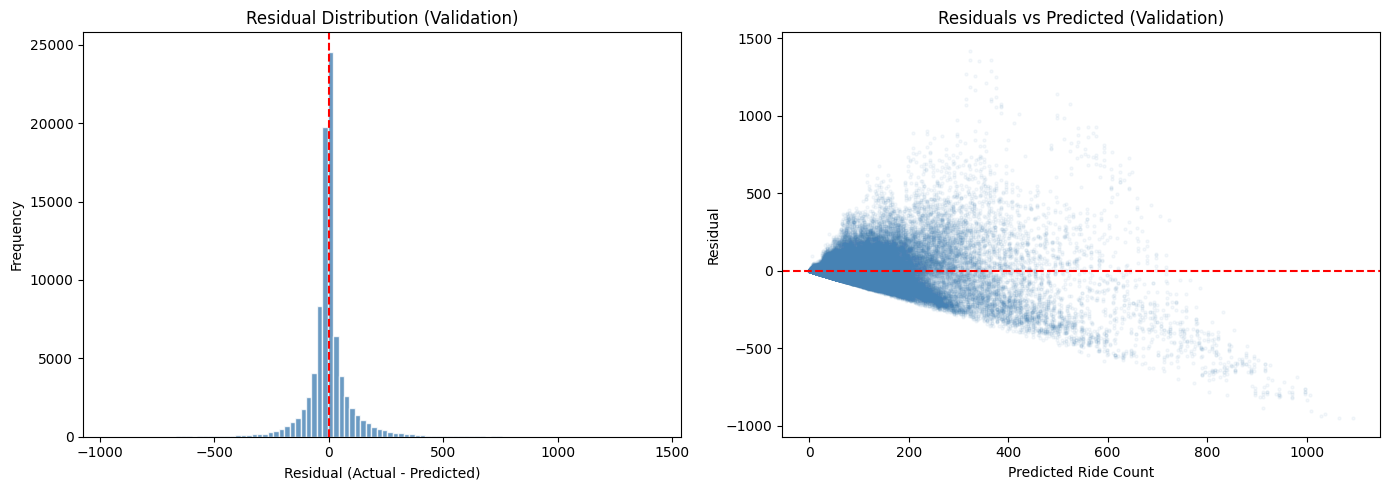

Mean residual: -0.10
Std residual:  105.16


In [19]:
# Residual distribution (original scale)
residuals_val = y_val_raw - y_pred_val_raw

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals_val, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residual Distribution (Validation)')
axes[0].set_xlabel('Residual (Actual - Predicted)')
axes[0].set_ylabel('Frequency')

axes[1].scatter(y_pred_val_raw, residuals_val, alpha=0.05, s=5, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted (Validation)')
axes[1].set_xlabel('Predicted Ride Count')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

print(f'Mean residual: {residuals_val.mean():.2f}')
print(f'Std residual:  {residuals_val.std():.2f}')

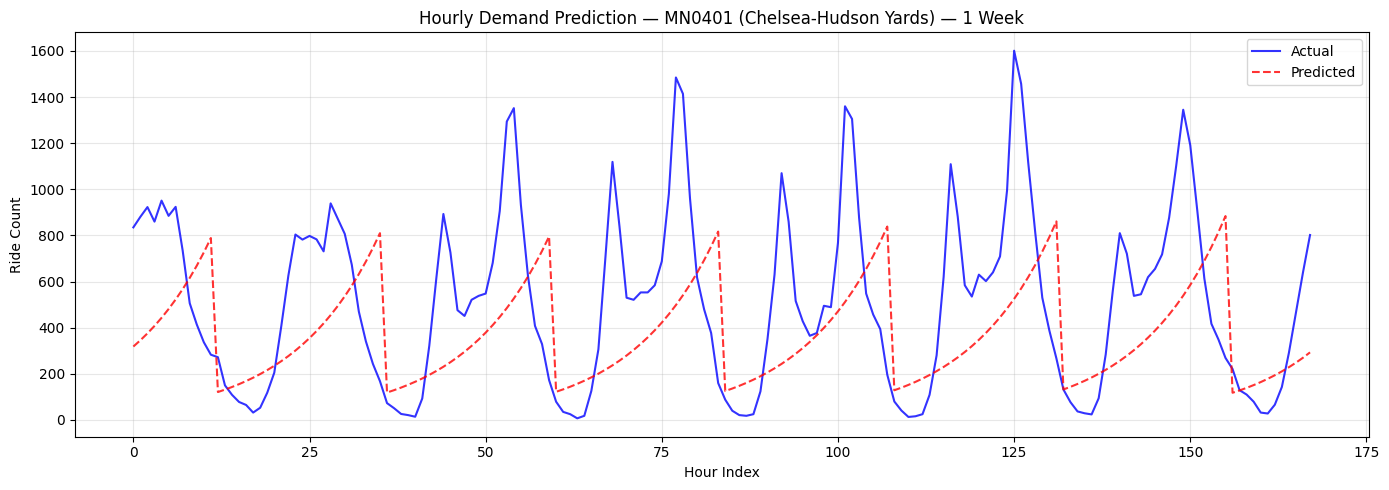

In [20]:
# Predicted vs Actual hourly demand for a sample neighborhood
sample_nta = 'MN0401'  # Chelsea-Hudson Yards (highest demand)

# Get a week of validation data for this NTA
val_df = df[val_mask].copy()
val_df['y_pred'] = y_pred_val_raw

nta_week = val_df[val_df['NTA2020'] == sample_nta].head(24 * 7)  # one week

plt.figure(figsize=(14, 5))
plt.plot(range(len(nta_week)), nta_week['ride_count'].values, 'b-', label='Actual', alpha=0.8)
plt.plot(range(len(nta_week)), nta_week['y_pred'].values, 'r--', label='Predicted', alpha=0.8)
plt.title(f'Hourly Demand Prediction — {sample_nta} (Chelsea-Hudson Yards) — 1 Week')
plt.xlabel('Hour Index')
plt.ylabel('Ride Count')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

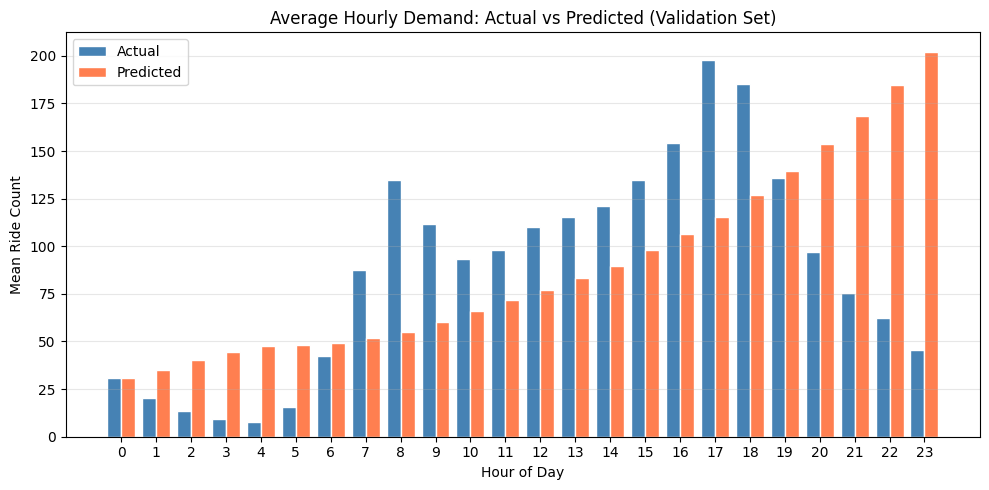

In [21]:
# Average predicted vs actual by hour of day (Validation set)
val_df = df[val_mask].copy()
val_df['y_pred'] = y_pred_val_raw

hourly_comparison = val_df.groupby('hour').agg(
    actual_mean=('ride_count', 'mean'),
    predicted_mean=('y_pred', 'mean')
)

plt.figure(figsize=(10, 5))
plt.bar(hourly_comparison.index - 0.2, hourly_comparison['actual_mean'], width=0.4, 
        label='Actual', color='steelblue', edgecolor='white')
plt.bar(hourly_comparison.index + 0.2, hourly_comparison['predicted_mean'], width=0.4, 
        label='Predicted', color='coral', edgecolor='white')
plt.title('Average Hourly Demand: Actual vs Predicted (Validation Set)')
plt.xlabel('Hour of Day')
plt.ylabel('Mean Ride Count')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
# 10. Model Comparison Summary

In [22]:
# Summary comparison table (original scale)
summary = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'R²'],
    'Normal Eq (Train)': [results_ne['Train']['RMSE'], results_ne['Train']['MAE'], results_ne['Train']['R2']],
    'Normal Eq (Val)':   [results_ne['Val']['RMSE'], results_ne['Val']['MAE'], results_ne['Val']['R2']],
    'Normal Eq (Test)':  [results_ne['Test']['RMSE'], results_ne['Test']['MAE'], results_ne['Test']['R2']],
    'Grad Desc (Train)': [results_gd['Train']['RMSE'], results_gd['Train']['MAE'], results_gd['Train']['R2']],
    'Grad Desc (Val)':   [results_gd['Val']['RMSE'], results_gd['Val']['MAE'], results_gd['Val']['R2']],
    'Grad Desc (Test)':  [results_gd['Test']['RMSE'], results_gd['Test']['MAE'], results_gd['Test']['R2']],
})
print('Original Scale Metrics:')
print(summary.round(4).to_string(index=False))

Original Scale Metrics:
Metric  Normal Eq (Train)  Normal Eq (Val)  Normal Eq (Test)  Grad Desc (Train)  Grad Desc (Val)  Grad Desc (Test)
  RMSE            86.5628         105.1575          132.0304            86.6950         105.3949          132.6316
   MAE            44.2275          56.2660           75.8770            44.2621          56.4279           76.3713
    R²             0.4132           0.4087           -1.8378             0.4114           0.4060           -1.8637


---
# 11. Discussion

### Why log-transform?

The raw `ride_count` distribution is heavily right-skewed (most values under 100, but peaks above 1000). Without log-transform, the model exhibited **heteroscedastic residuals** — errors fanned out for high-demand predictions, and the model systematically underpredicted peak hours. The log-transform compresses this range and produces a more symmetric target distribution, which better satisfies the assumptions of linear regression.

### Why is the test R² negative?

The test set covers **November–December 2025**, when Citibike demand drops significantly due to cold weather and holidays. The training set (January–September) has a mean ride count of ~73, while the test set drops to ~49. This **distributional shift** means the model trained on warmer months struggles to generalize to cold-weather patterns.

A negative R² means the model's predictions are worse than simply predicting the test set's mean. This is a known challenge with chronological splits in seasonal data.

### Key takeaways

1. **Log-space R²** is substantially higher than original-scale R², confirming the transform helps the model learn relative demand patterns even if absolute ride count prediction remains challenging.
2. **Validation R²** is a better indicator of model quality since the validation period (Sep–Nov) is closer in distribution to training.
3. **Weather features** (temperature, precipitation, wind speed) — not yet included in this dataset — would significantly help the model capture the seasonal demand shifts and improve test-set performance.
4. **The Normal Equation and Gradient Descent converge to similar solutions**, confirming our gradient descent implementation is correct.
5. **Top neighborhood coefficients** (e.g., Chelsea-Hudson Yards, Midtown) align with known high-demand areas.
6. **Next steps:** Integrate weather features.